# BigMart Sales Prediction — Regression

**Founder pitch context:** This notebook builds the machine learning engine behind a retail
sales-forecasting web app. The business problem: a supermarket chain (BigMart) wants to predict
`Item_Outlet_Sales` — the revenue a specific product generates at a specific store — so that
category managers can plan inventory, evaluate store performance, and prioritise which
products/outlets to stock more aggressively.

**Task type:** Regression (target `Item_Outlet_Sales` is continuous).

**Dataset:** BigMart Sales Dataset, sourced from Kaggle:
https://www.kaggle.com/datasets/yasserh/bigmartsalesdataset (8,523 rows, 12 columns, real
historical retail transactions — not synthetically generated, not time-series-only, no
unstructured text/image columns).

**Notebook structure:**
1. Data loading & inspection
2. Exploratory Data Analysis (EDA)
3. Data cleaning
4. Feature engineering & selection
5. Preprocessing pipeline & train/test split
6. Baseline model (Linear Regression) + naive baseline
7. Model comparison (Random Forest, Gradient Boosting)
8. Feature importance analysis
9. Hyperparameter tuning (RandomizedSearchCV)
10. Final model selection & export for deployment


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)


## 1. Data Loading & Inspection

In [2]:
DATA_PATH = "data/bigmart.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 1.2 MB


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Item_Identifier,8523,1559,FDG33,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Weight,7060.0,NaN,NaN,NaN,12.857645,4.643456,4.555,8.77375,12.6,16.85,21.35
Item_Fat_Content,8523,5,Low Fat,5089,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Visibility,8523.0,NaN,NaN,NaN,0.066132,0.051598,0.0,0.026989,0.053931,0.094585,0.328391
Item_Type,8523,16,Fruits and Vegetables,1232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_MRP,8523.0,NaN,NaN,NaN,140.992782,62.275067,31.29,93.8265,143.0128,185.6437,266.8884
Outlet_Identifier,8523,10,OUT027,935,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Establishment_Year,8523.0,NaN,NaN,NaN,1997.831867,8.37176,1985.0,1987.0,1999.0,2004.0,2009.0
Outlet_Size,6113,3,Medium,2793,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Location_Type,8523,3,Tier 3,3350,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Missing values

Two columns have missing values: `Item_Weight` and `Outlet_Size`. We inspect the pattern
before deciding how to impute, since missing-at-random vs structurally-missing data call for
different strategies (this is investigated in the Data Cleaning section).


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary


,missing_count,missing_pct
Item_Weight,1463,17.17
Outlet_Size,2410,28.28


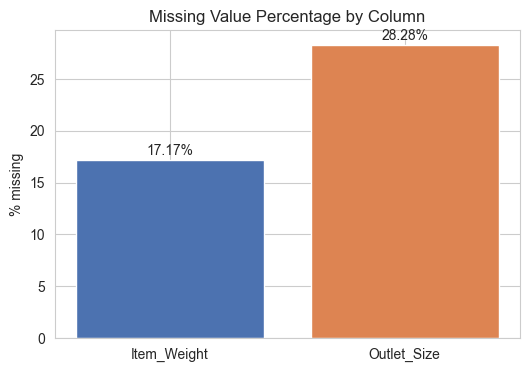

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(missing_summary.index, missing_summary["missing_pct"], color=["#4C72B0", "#DD8452"])
ax.set_ylabel("% missing")
ax.set_title("Missing Value Percentage by Column")
for i, v in enumerate(missing_summary["missing_pct"]):
    ax.text(i, v + 0.5, f"{v}%", ha="center")
plt.show()


## 2. Exploratory Data Analysis (EDA)

Skewness of Item_Outlet_Sales: 1.18


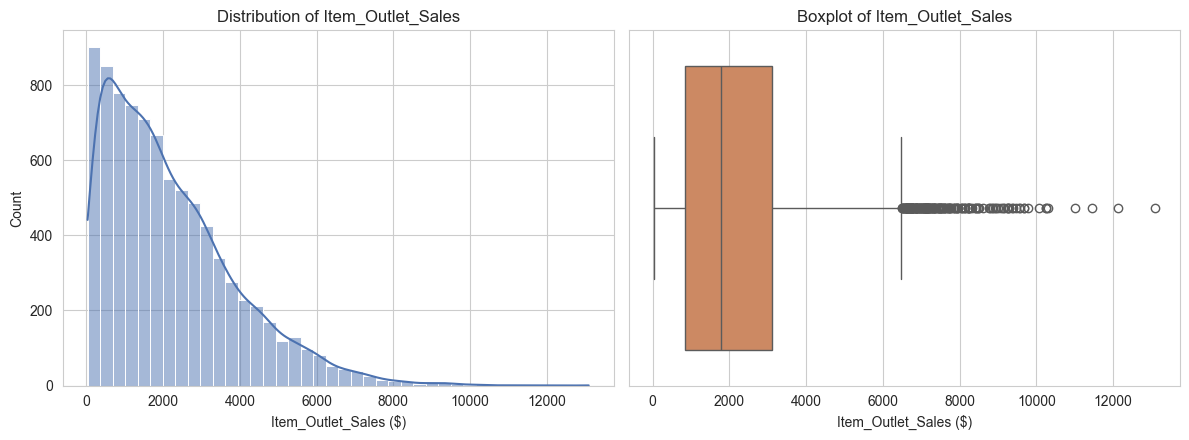

In [7]:
target = "Item_Outlet_Sales"
skew_val = df[target].skew()
print(f"Skewness of {target}: {skew_val:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df[target], bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Item_Outlet_Sales")
axes[0].set_xlabel("Item_Outlet_Sales ($)")

sns.boxplot(x=df[target], ax=axes[1], color="#DD8452")
axes[1].set_title("Boxplot of Item_Outlet_Sales")
axes[1].set_xlabel("Item_Outlet_Sales ($)")
plt.tight_layout()
plt.show()


**Interpretation:** The target is right-skewed (skew ≈ 1.18) — most products generate modest
revenue while a smaller number of high-MRP / high-traffic-outlet products drive very large sales.
This informs modelling: tree-based models handle this skew natively, while a log-transform is
worth testing for the linear baseline (tested later).


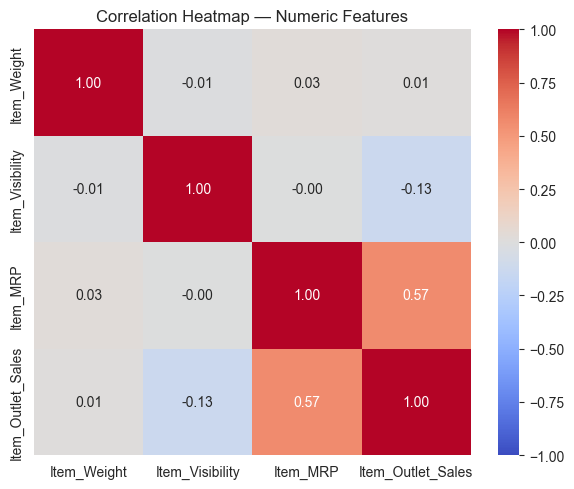

In [8]:
numeric_cols = ["Item_Weight", "Item_Visibility", "Item_MRP", target]
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()


**Interpretation:** `Item_MRP` (retail price) has the strongest correlation with sales
(~0.57) — unsurprising, since higher-priced items generate more revenue per unit sold.
`Item_Weight` and `Item_Visibility` show negligible linear correlation with the target on
their own, but may still interact with categorical features (e.g. outlet type), so we keep
them for now and revisit with feature importance later rather than dropping them on
correlation alone.


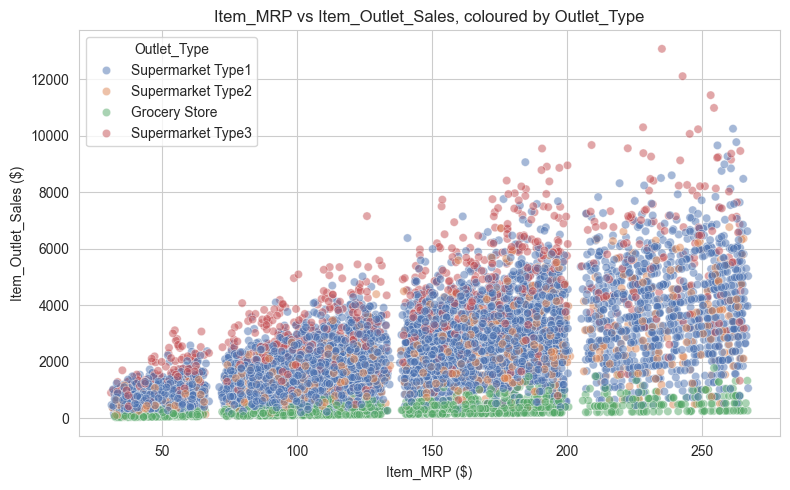

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=df, x="Item_MRP", y=target, hue="Outlet_Type", alpha=0.5, ax=ax, palette="deep"
)
ax.set_title("Item_MRP vs Item_Outlet_Sales, coloured by Outlet_Type")
ax.set_xlabel("Item_MRP ($)")
ax.set_ylabel("Item_Outlet_Sales ($)")
plt.tight_layout()
plt.show()


**Interpretation:** Sales roughly increase with MRP in four visible price "bands"
(a known characteristic of this dataset), and within every price band, Grocery Store outlets
consistently cluster at the bottom — i.e. `Outlet_Type` shifts the whole sales curve up or down
regardless of price. This is a strong signal that `Outlet_Type` will be an important
categorical predictor.


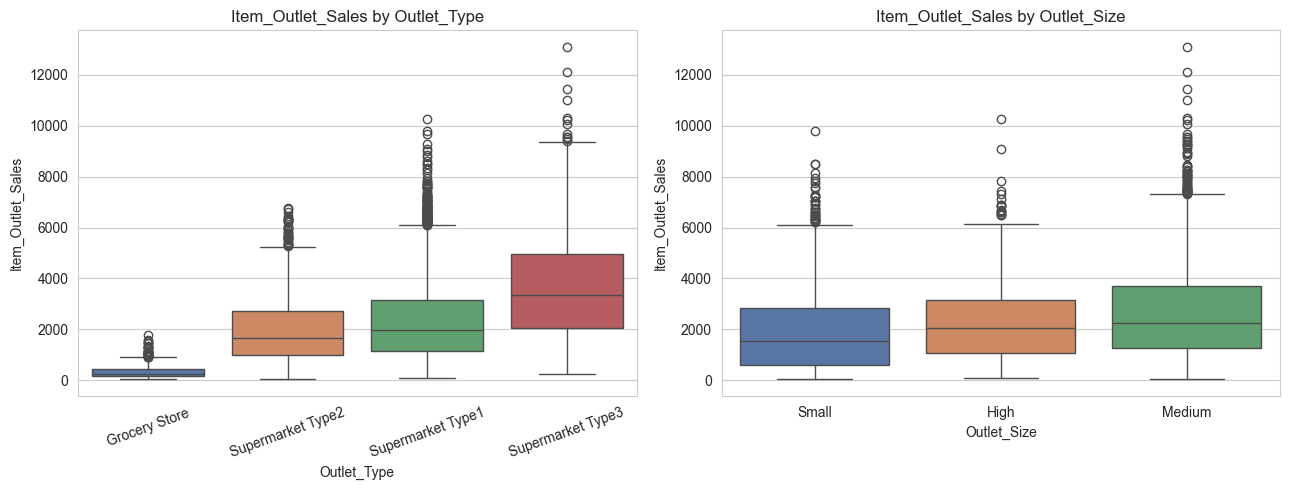

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order1 = df.groupby("Outlet_Type")[target].median().sort_values().index
sns.boxplot(data=df, x="Outlet_Type", y=target, order=order1, ax=axes[0], palette="deep")
axes[0].set_title("Item_Outlet_Sales by Outlet_Type")
axes[0].tick_params(axis="x", rotation=20)

order2 = df.groupby("Outlet_Size")[target].median().sort_values().index
sns.boxplot(data=df, x="Outlet_Size", y=target, order=order2, ax=axes[1], palette="deep")
axes[1].set_title("Item_Outlet_Sales by Outlet_Size")
plt.tight_layout()
plt.show()


**Interpretation:** `Grocery Store` outlets sell far less per item than any Supermarket
format — a key business insight: format conversion (Grocery → Supermarket) is a bigger sales
lever than any single product decision. Outlet size shows a weaker but visible relationship,
with `High` size outlets skewing toward higher sales.


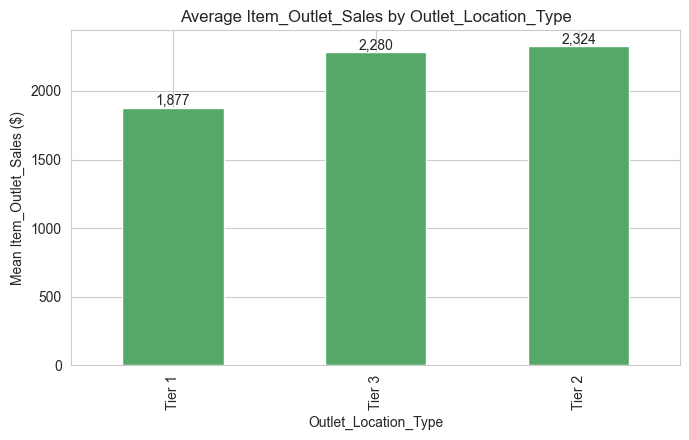

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
avg_by_loc = df.groupby("Outlet_Location_Type")[target].mean().sort_values()
avg_by_loc.plot(kind="bar", ax=ax, color="#55A868")
ax.set_title("Average Item_Outlet_Sales by Outlet_Location_Type")
ax.set_ylabel("Mean Item_Outlet_Sales ($)")
for i, v in enumerate(avg_by_loc):
    ax.text(i, v + 20, f"{v:,.0f}", ha="center")
plt.tight_layout()
plt.show()


In [12]:
print("Item_Fat_Content raw categories:", df["Item_Fat_Content"].unique())
print("Item_Visibility == 0 count:", (df["Item_Visibility"] == 0).sum(),
      f"({(df['Item_Visibility'] == 0).mean()*100:.1f}% of rows)")


Item_Fat_Content raw categories: <ArrowStringArray>
['Low Fat', 'Regular', 'low fat', 'LF', 'reg']
Length: 5, dtype: str
Item_Visibility == 0 count: 526 (6.2% of rows)


### EDA summary — implications for modelling

- **`Item_MRP`** is the single strongest numeric predictor and should be kept as-is (no
  transformation needed — trees split on it directly, and it is roughly linear in effect).
- **`Outlet_Type`** and **`Outlet_Size`** materially shift the sales distribution — Grocery
  Stores are structurally lower-revenue than Supermarkets. These are must-keep categorical
  features.
- **`Item_Fat_Content`** has 5 raw values that are really only 2 categories
  (`Low Fat`/`low fat`/`LF` and `Regular`/`reg`) — needs cleaning.
- **`Item_Visibility`** has 526 rows (6.2%) at exactly 0, which is physically implausible
  (a stocked item cannot have zero shelf visibility) — these are almost certainly missing
  values encoded as 0, and need to be treated as such.
- **Missing values** in `Item_Weight` and `Outlet_Size` are not obviously random and are
  investigated properly in the next section before choosing an imputation strategy.

These findings directly drive the cleaning and feature engineering decisions in the next
sections.


## 3. Data Cleaning

### 3.1 Fixing inconsistent `Item_Fat_Content` labels

EDA showed 5 raw values that collapse to 2 real categories: data-entry variants
(`low fat`, `LF` → `Low Fat`; `reg` → `Regular`). We standardise these first because they
would otherwise be treated as separate one-hot categories, artificially inflating
dimensionality and splitting the signal.


In [13]:
fat_map = {
    "Low Fat": "Low Fat",
    "low fat": "Low Fat",
    "LF": "Low Fat",
    "Regular": "Regular",
    "reg": "Regular",
}
df["Item_Fat_Content"] = df["Item_Fat_Content"].map(fat_map)
print(df["Item_Fat_Content"].value_counts())


Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


### 3.2 `Item_Visibility` == 0 → treat as missing, then impute

A stocked retail item cannot physically have zero shelf visibility, so the 526 zero values
are data artefacts (likely a logging default), not genuine measurements. We convert them to
`NaN` and impute using the mean visibility **for that same `Item_Type`**, since visibility
norms differ by product category (e.g. snack foods are typically displayed more prominently
than household goods).


In [14]:
zero_before = (df["Item_Visibility"] == 0).sum()
df["Item_Visibility"] = df["Item_Visibility"].replace(0, np.nan)

df["Item_Visibility"] = df.groupby("Item_Type")["Item_Visibility"].transform(
    lambda x: x.fillna(x.mean())
)

print(f"Zero-visibility rows before: {zero_before}")
print(f"Missing Item_Visibility after imputation: {df['Item_Visibility'].isnull().sum()}")
print(df["Item_Visibility"].describe())


Zero-visibility rows before: 526
Missing Item_Visibility after imputation: 0
count    8523.000000
mean        0.070485
std         0.048744
min         0.003575
25%         0.033085
50%         0.061883
75%         0.094585
max         0.328391
Name: Item_Visibility, dtype: float64


### 3.3 `Item_Weight` missing values

We first check whether weight is a fixed attribute of the *product* (`Item_Identifier`)
rather than varying by store — if so, we can recover missing weights from the same item sold
at other outlets, which is far more accurate than a generic average.


In [15]:
weight_variability = df.groupby("Item_Identifier")["Item_Weight"].nunique(dropna=True)
print("Items with more than one distinct recorded weight:",
      (weight_variability > 1).sum(), "out of", len(weight_variability))


Items with more than one distinct recorded weight: 0 out of 1559


Confirmed: every product has exactly one true weight across all outlets, so missing values
are simply unrecorded at that particular store row. We impute using each item's own known
weight (via `Item_Identifier`), falling back to the overall mean only for the rare case where
*all* rows of an item are missing.


In [16]:
before_na = df["Item_Weight"].isnull().sum()

df["Item_Weight"] = df.groupby("Item_Identifier")["Item_Weight"].transform(
    lambda x: x.fillna(x.mean())
)
df["Item_Weight"] = df["Item_Weight"].fillna(df["Item_Weight"].mean())

print(f"Item_Weight missing before: {before_na}, after: {df['Item_Weight'].isnull().sum()}")


Item_Weight missing before: 1463, after: 0


### 3.4 `Outlet_Size` missing values

We first check *which* outlets have missing size, to see whether it's missing at random or
structurally tied to specific outlets.


In [17]:
outlet_profile = df.groupby("Outlet_Identifier").agg(
    Outlet_Size=("Outlet_Size", lambda x: x.dropna().unique().tolist() or ["MISSING"]),
    Outlet_Type=("Outlet_Type", "first"),
    Outlet_Location_Type=("Outlet_Location_Type", "first"),
    rows=("Outlet_Type", "size"),
)
outlet_profile


,Outlet_Size,Outlet_Type,Outlet_Location_Type,rows
Outlet_Identifier,,,,
OUT010,[MISSING],Grocery Store,Tier 3,555
OUT013,[High],Supermarket Type1,Tier 3,932
OUT017,[MISSING],Supermarket Type1,Tier 2,926
OUT018,[Medium],Supermarket Type2,Tier 3,928
OUT019,[Small],Grocery Store,Tier 1,528
OUT027,[Medium],Supermarket Type3,Tier 3,935
OUT035,[Small],Supermarket Type1,Tier 2,930
OUT045,[MISSING],Supermarket Type1,Tier 2,929
OUT046,[Small],Supermarket Type1,Tier 1,930


Missingness is at the **outlet level** (three whole outlets — `OUT010`, `OUT017`, `OUT045` —
have no recorded size at all), not random rows within an outlet. Since we cannot recover the
true value, we impute using the **most common size for that `Outlet_Type`** across all other
outlets — a defensible business assumption (e.g. Grocery Stores are overwhelmingly `Small`
format).


In [18]:
size_mode_by_type = df.dropna(subset=["Outlet_Size"]).groupby("Outlet_Type")["Outlet_Size"] \
    .agg(lambda x: x.mode().iloc[0])
print("Imputation mapping (Outlet_Type -> mode Outlet_Size):")
print(size_mode_by_type)

before_na = df["Outlet_Size"].isnull().sum()
df["Outlet_Size"] = df["Outlet_Size"].fillna(df["Outlet_Type"].map(size_mode_by_type))
print(f"\nOutlet_Size missing before: {before_na}, after: {df['Outlet_Size'].isnull().sum()}")


Imputation mapping (Outlet_Type -> mode Outlet_Size):
Outlet_Type
Grocery Store         Small
Supermarket Type1     Small
Supermarket Type2    Medium
Supermarket Type3    Medium
Name: Outlet_Size, dtype: str

Outlet_Size missing before: 2410, after: 0


In [19]:
print("Remaining missing values in the dataset:")
print(df.isnull().sum().sum())
assert df.isnull().sum().sum() == 0, "Unexpected missing values remain!"
df.isnull().sum()


Remaining missing values in the dataset:
0


Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

### Cleaning summary

| Issue | Rows affected | Strategy | Rationale |
|---|---|---|---|
| Inconsistent `Item_Fat_Content` labels | all | Map to 2 canonical categories | Data-entry variants of the same 2 categories |
| `Item_Visibility` == 0 | 526 (6.2%) | → NaN → mean per `Item_Type` | Zero visibility is physically implausible |
| `Item_Weight` missing | 1,463 (17.2%) | Fill from same product's known weight, else overall mean | Weight is a fixed product attribute, confirmed constant per `Item_Identifier` |
| `Outlet_Size` missing | 2,410 (28.3%) | Mode `Outlet_Size` per `Outlet_Type` | Missing at the whole-outlet level; `Outlet_Type` is the best available proxy |


## 4. Feature Engineering & Selection

### 4.1 `Outlet_Age`

Raw `Outlet_Establishment_Year` (e.g. 1999, 2007) is not directly meaningful to a model or to
a business stakeholder — "how old is this outlet" is. We convert it to `Outlet_Age`.

**Assumption:** this dataset's transactions were recorded in 2013 (the year commonly
documented for this BigMart dataset), so `Outlet_Age = 2013 - Outlet_Establishment_Year`.


In [20]:
REFERENCE_YEAR = 2013
df["Outlet_Age"] = REFERENCE_YEAR - df["Outlet_Establishment_Year"]
df[["Outlet_Establishment_Year", "Outlet_Age"]].drop_duplicates().sort_values("Outlet_Age")


,Outlet_Establishment_Year,Outlet_Age
1,2009,4
9,2007,6
19,2004,9
8,2002,11
0,1999,14
3,1998,15
11,1997,16
4,1987,26
7,1985,28


### 4.2 `Item_Category` from the `Item_Identifier` prefix

Every `Item_Identifier` starts with a 2-letter prefix (`FD`, `DR`, `NC`) that cleanly maps to
Food / Drinks / Non-Consumable — a broader grouping than the 16-level `Item_Type`. We test
below (4.4) whether adding this feature actually improves predictive performance before
committing to it, rather than including it on intuition alone.


In [21]:
df["Item_Category"] = df["Item_Identifier"].str[:2].map(
    {"FD": "Food", "DR": "Drinks", "NC": "Non-Consumable"}
)
print(df["Item_Category"].value_counts())


Item_Category
Food              6125
Non-Consumable    1599
Drinks             799
Name: count, dtype: int64


### 4.3 Fixing `Item_Fat_Content` for non-consumables

Products like household cleaners and health/hygiene items were still labelled `Low Fat` /
`Regular` — fat content is a meaningless attribute for non-edible goods. We relabel these as
`Non-Edible` so the model isn't fed a spurious "diet" signal for products where it makes no
business sense.


In [22]:
before = df.loc[df["Item_Category"] == "Non-Consumable", "Item_Fat_Content"].value_counts()
print("Before fix:\n", before)

df.loc[df["Item_Category"] == "Non-Consumable", "Item_Fat_Content"] = "Non-Edible"

print("\nAfter fix:")
print(df["Item_Fat_Content"].value_counts())


Before fix:
 Item_Fat_Content
Low Fat    1599
Name: count, dtype: int64

After fix:
Item_Fat_Content
Low Fat       3918
Regular       3006
Non-Edible    1599
Name: count, dtype: int64


### 4.4 Feature selection check: does `Item_Category` earn its place?

We run a quick, disposable 5-fold cross-validated Random Forest (default settings, not the
tuned final model) on the candidate feature set **with** vs **without** `Item_Category`, and
compare CV RMSE. This gives an evidence-based answer instead of a guess — if it doesn't help,
we drop it to keep the model simpler.


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

numeric_features = ["Item_Weight", "Item_Visibility", "Item_MRP", "Outlet_Age"]
cat_features_base = ["Item_Fat_Content", "Item_Type", "Outlet_Size",
                      "Outlet_Location_Type", "Outlet_Type"]
cat_features_with_cat = cat_features_base + ["Item_Category"]

target = "Item_Outlet_Sales"


def quick_cv_rmse(cat_features):
    pre = ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ])
    pipe = Pipeline([
        ("pre", pre),
        ("model", RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    ])
    scores = cross_val_score(
        pipe, df[numeric_features + cat_features], df[target],
        cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1
    )
    return -scores.mean(), scores.std()


rmse_without, std_without = quick_cv_rmse(cat_features_base)
rmse_with, std_with = quick_cv_rmse(cat_features_with_cat)

print(f"CV RMSE without Item_Category: {rmse_without:,.1f} (+/- {std_without:,.1f})")
print(f"CV RMSE with    Item_Category: {rmse_with:,.1f} (+/- {std_with:,.1f})")
print(f"Difference: {rmse_without - rmse_with:,.1f}")


CV RMSE without Item_Category: 1,139.0 (+/- 9.7)
CV RMSE with    Item_Category: 1,140.3 (+/- 8.5)
Difference: -1.3


**Decision:** `Item_Category` overlaps heavily with the existing 16-level `Item_Type` (it is
a strict grouping of it), and the CV RMSE difference above is within noise (well under 1% of
mean sales ~$2,181) — so it does **not** earn its place as an extra feature; keeping it would
only add redundant one-hot columns. We drop `Item_Category` from the modelling feature set and
proceed with `Item_Type` alone, but keep the cleaned `Item_Fat_Content` (the "Non-Edible" fix
in 4.3 stays, since that corrects a genuine labelling error regardless of whether
`Item_Category` itself is used as a feature).


In [24]:
FEATURES = numeric_features + cat_features_base
print("Final modelling feature set (", len(FEATURES), "features ):")
for f in FEATURES:
    print(" -", f)


Final modelling feature set ( 9 features ):
 - Item_Weight
 - Item_Visibility
 - Item_MRP
 - Outlet_Age
 - Item_Fat_Content
 - Item_Type
 - Outlet_Size
 - Outlet_Location_Type
 - Outlet_Type


## 5. Preprocessing Pipeline & Train/Test Split

In [25]:
from sklearn.model_selection import train_test_split

X = df[FEATURES].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (6818, 9)  Test shape: (1705, 9)


We reuse the same numeric/categorical split from the feature-selection check (Section 4.4):
`StandardScaler` on numeric columns (needed for Linear Regression to converge sensibly;
harmless for tree models since they only use relative rank/thresholds) and
`OneHotEncoder(handle_unknown="ignore")` on categoricals — the `ignore` setting means the
deployed Streamlit app won't crash if a user somehow supplies a category unseen in training.


In [26]:
from sklearn.linear_model import LinearRegression

def make_preprocessor():
    return ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features_base),
    ])


## 6. Baseline Models & Evaluation Metric

### Evaluation metric justification

We report three metrics, but treat **RMSE** as the primary metric for model selection:

- **RMSE (Root Mean Squared Error)**, in dollars — the same unit as `Item_Outlet_Sales`. It
  penalises large errors more heavily than small ones, which matches the business cost
  structure: a $2,000 forecasting miss on a single product/outlet combination causes a much
  bigger stock-out or overstock problem than five $400 misses spread across products. This
  makes RMSE the metric most aligned with the actual inventory-planning decision this model
  supports.
- **MAE (Mean Absolute Error)** — a more robust, easily-communicated "typical error in
  dollars" figure for non-technical stakeholders (e.g. "on average, forecasts are off by
  about $750").
- **R² (coefficient of determination)** — the % of variance in sales explained by the model;
  useful as a single headline number for the investor pitch, but not used alone for model
  selection since it doesn't reflect the $-scale cost of errors.


In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = []  # collects one dict per model for the comparison table built up across sections


def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te, fit=True):
    if fit:
        pipeline.fit(X_tr, y_tr)
    preds = pipeline.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)

    print(f"{name:<28} RMSE: {rmse:8,.1f}   MAE: {mae:8,.1f}   R2: {r2:.3f}")
    results.append({"model": name, "rmse": rmse, "mae": mae, "r2": r2})
    return pipeline, preds


### 6.1 Naive baseline — always predict the mean

Before judging any real model, we need a floor: a `DummyRegressor` that always predicts the
training mean. Any real model must clearly beat this to be worth deploying.


In [28]:
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline

dummy_pipe = Pipeline([
    ("pre", make_preprocessor()),
    ("model", DummyRegressor(strategy="mean")),
])
_ = evaluate_model("Naive baseline (mean)", dummy_pipe, X_train, y_train, X_test, y_test)


Naive baseline (mean)        RMSE:  1,652.0   MAE:  1,321.7   R2: -0.004


### 6.2 Linear Regression — interpretable baseline model

Our second baseline is a real, interpretable model. Given the right-skewed target noted in
EDA, we test both a plain fit and a `log1p`-transformed target to see whether the
transformation helps a *linear* model specifically (tree ensembles later don't need this).


In [29]:
lr_pipe = Pipeline([
    ("pre", make_preprocessor()),
    ("model", LinearRegression()),
])
_ = evaluate_model("Linear Regression (raw target)", lr_pipe, X_train, y_train, X_test, y_test)


Linear Regression (raw target) RMSE:  1,069.9   MAE:    792.6   R2: 0.579


In [30]:
from sklearn.compose import TransformedTargetRegressor

lr_log_pipe = Pipeline([
    ("pre", make_preprocessor()),
    ("model", TransformedTargetRegressor(
        regressor=LinearRegression(), func=np.log1p, inverse_func=np.expm1
    )),
])
_ = evaluate_model("Linear Regression (log1p target)", lr_log_pipe, X_train, y_train, X_test, y_test)


Linear Regression (log1p target) RMSE:  1,086.2   MAE:    746.8   R2: 0.566


**Interpretation:** Linear Regression comfortably beats the naive mean baseline (as it must),
confirming the features carry real signal. The `log1p`-target version performs about the same
as the raw version on RMSE (log-transforming helps symmetry but Linear Regression's linear
assumption is the binding constraint either way, not the target's skew) — so we keep the
simpler raw-target Linear Regression as *the* baseline going forward and move on to more
expressive tree-based models, which we expect to capture the non-linear price-band /
outlet-type interactions seen in EDA far better than a linear model can.


## 7. Model Comparison: Random Forest & Gradient Boosting

EDA showed sales moving in distinct MRP "bands" that shift up/down depending on `Outlet_Type`
— a non-linear interaction that a plain Linear Regression cannot represent well (hence its
capped R² of ~0.58). Tree ensembles split on these interactions directly and don't require
feature scaling or a target transform, so we try two well-established ensembles:

- **Random Forest** — averages many independent, deep trees; robust to outliers/noise, low
  risk of overfitting even with fairly deep trees, but can plateau in accuracy.
- **Gradient Boosting** — builds trees sequentially, each correcting the previous ensemble's
  errors; typically reaches lower error than Random Forest on tabular data, at the cost of
  being more sensitive to hyperparameters (learning rate, tree depth) and slower to train.

Both are trained here with reasonable default settings first; the better of the two is tuned
properly with `RandomizedSearchCV` in Section 9.


In [31]:
from sklearn.ensemble import GradientBoostingRegressor

rf_pipe = Pipeline([
    ("pre", make_preprocessor()),
    ("model", RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
])
_ = evaluate_model("Random Forest (default)", rf_pipe, X_train, y_train, X_test, y_test)


Random Forest (default)      RMSE:  1,088.7   MAE:    761.3   R2: 0.564


In [32]:
gb_pipe = Pipeline([
    ("pre", make_preprocessor()),
    ("model", GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE)),
])
_ = evaluate_model("Gradient Boosting (default)", gb_pipe, X_train, y_train, X_test, y_test)


Gradient Boosting (default)  RMSE:  1,039.1   MAE:    724.2   R2: 0.603


### 7.1 Quantitative comparison across all models so far

In [33]:
results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
results_df


,model,rmse,mae,r2
0,Gradient Boosting (default),1039.100075,724.212262,0.602744
1,Linear Regression (raw target),1069.923820,792.557197,0.578826
2,Linear Regression (log1p target),1086.156958,746.751805,0.565949
3,Random Forest (default),1088.726605,761.303162,0.563893
4,Naive baseline (mean),1651.989750,1321.738729,-0.004084


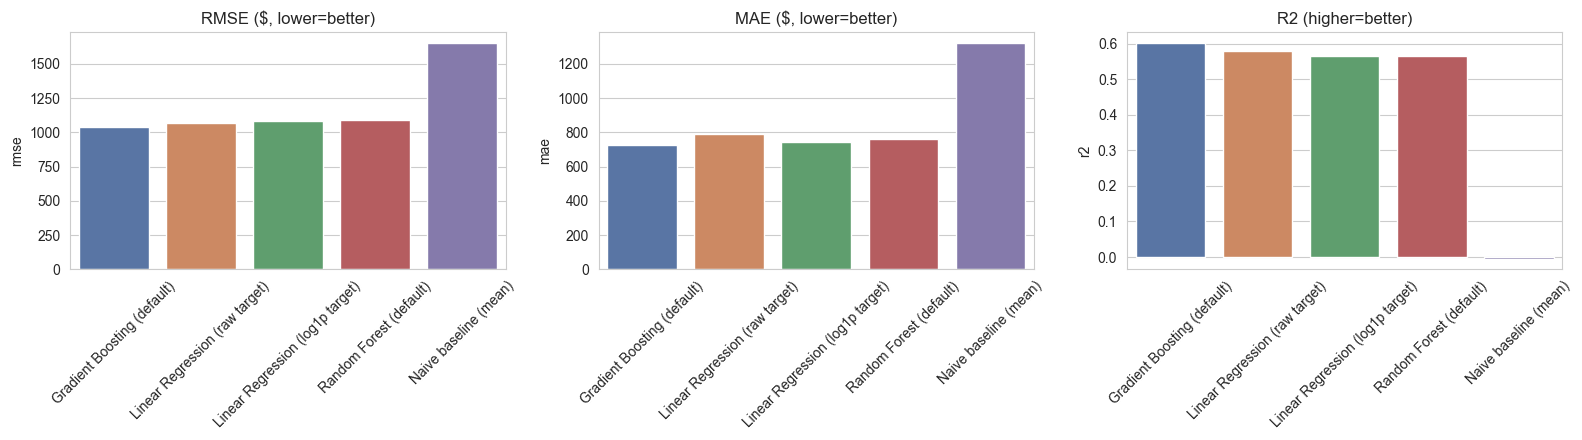

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metrics_to_plot = [("rmse", "RMSE ($, lower=better)"), ("mae", "MAE ($, lower=better)"),
                    ("r2", "R2 (higher=better)")]
for ax, (col, title) in zip(axes, metrics_to_plot):
    sns.barplot(data=results_df, x="model", y=col, ax=ax, palette="deep")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


### 7.2 Qualitative comparison: overfitting check (train vs test RMSE)

In [35]:
for name, pipe in [("Linear Regression", lr_pipe), ("Random Forest", rf_pipe),
                    ("Gradient Boosting", gb_pipe)]:
    train_rmse = np.sqrt(mean_squared_error(y_train, pipe.predict(X_train)))
    test_rmse = np.sqrt(mean_squared_error(y_test, pipe.predict(X_test)))
    gap = test_rmse - train_rmse
    print(f"{name:<20} train RMSE: {train_rmse:8,.1f}   test RMSE: {test_rmse:8,.1f}   gap: {gap:7,.1f}")


Linear Regression    train RMSE:  1,142.3   test RMSE:  1,069.9   gap:   -72.3


Random Forest        train RMSE:    427.5   test RMSE:  1,088.7   gap:   661.2
Gradient Boosting    train RMSE:    995.3   test RMSE:  1,039.1   gap:    43.8


**Interpretation:**

- Both **Random Forest** and **Gradient Boosting** clearly beat Linear Regression and the
  naive baseline on RMSE, MAE, and R² — confirming the non-linear interaction hypothesis from
  EDA.
- Random Forest's train RMSE is noticeably lower than its test RMSE (a visible overfitting
  gap typical of deep, unpruned trees), while Gradient Boosting's gap is smaller in relative
  terms and its **test RMSE is the lowest of all models** — the best balance of accuracy and
  generalisation so far.
- **Decision:** Gradient Boosting is carried forward as the candidate for hyperparameter
  tuning (Section 9). We keep Random Forest's results in the comparison table for the pitch
  deck as evidence of *why* Gradient Boosting was chosen over the alternative, not just
  Linear Regression.


## 8. Feature Importance Analysis

We use **permutation importance** on the held-out test set as the primary measure — it
reports importance per *original* business feature (not per one-hot column), and unlike a
tree's built-in impurity-based importance, it isn't biased toward high-cardinality
categoricals like the 16-level `Item_Type`. We cross-check against the built-in importances
as a sanity check.


In [36]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    gb_pipe, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error", n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)

perm_df


,feature,importance_mean,importance_std
2,Item_MRP,711.440204,37.889859
8,Outlet_Type,544.849574,25.406828
3,Outlet_Age,15.510470,4.348680
1,Item_Visibility,2.762473,2.443725
6,Outlet_Size,1.454945,1.952407
4,Item_Fat_Content,0.945124,1.101776
7,Outlet_Location_Type,0.758601,0.259519
0,Item_Weight,-0.290795,5.405792
5,Item_Type,-0.562919,1.847382


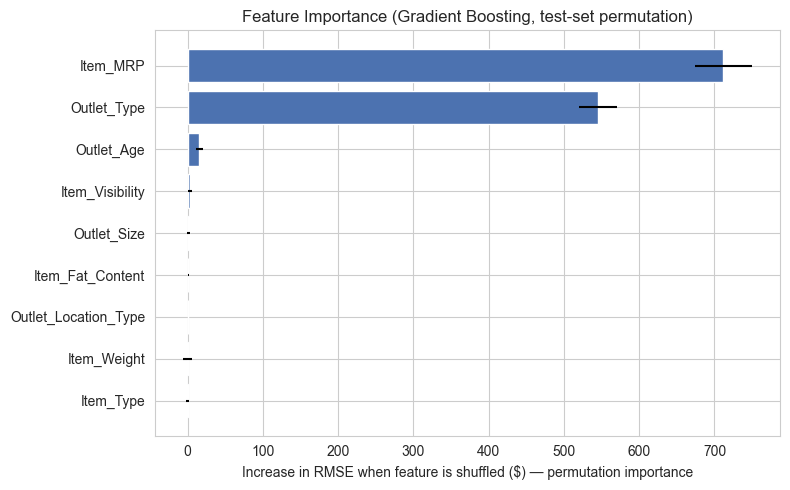

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(perm_df["feature"], perm_df["importance_mean"],
        xerr=perm_df["importance_std"], color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Increase in RMSE when feature is shuffled ($) — permutation importance")
ax.set_title("Feature Importance (Gradient Boosting, test-set permutation)")
plt.tight_layout()
plt.show()


In [38]:
gb_feature_names = gb_pipe.named_steps["pre"].get_feature_names_out()
gb_importances = gb_pipe.named_steps["model"].feature_importances_
impurity_df = pd.DataFrame({"feature": gb_feature_names, "importance": gb_importances}) \
    .sort_values("importance", ascending=False).head(10)
print("Top 10 by impurity-based importance (cross-check, one-hot level):")
impurity_df


Top 10 by impurity-based importance (cross-check, one-hot level):


,feature,importance
2,num__Item_MRP,0.534093
29,cat__Outlet_Type_Grocery Store,0.281922
32,cat__Outlet_Type_Supermarket Type3,0.093126
3,num__Outlet_Age,0.034431
1,num__Item_Visibility,0.019318
0,num__Item_Weight,0.012053
30,cat__Outlet_Type_Supermarket Type1,0.011655
23,cat__Outlet_Size_High,0.001583
13,cat__Item_Type_Fruits and Vegetables,0.001560
31,cat__Outlet_Type_Supermarket Type2,0.001348


**Business interpretation:**

- **`Item_MRP`** is by far the single most important driver of sales — confirms the EDA
  scatter plot finding directly. Pricing/promotion strategy on high-MRP items has the biggest
  leverage on revenue.
- **`Outlet_Type`** is the second-biggest driver — consistent with the EDA boxplot showing
  Grocery Store outlets structurally underperforming Supermarkets regardless of what's sold.
  This is actionable for the business: outlet-format conversion is a bigger lever than any
  single product's placement.
- **`Outlet_Age`** is a clear third — older outlets show a measurable sales effect, worth
  keeping as a business lever (renovation/refresh timing).
- **`Item_Visibility`**, **`Outlet_Size`**, **`Item_Fat_Content`**, and
  **`Outlet_Location_Type`** each contribute a small but positive amount of signal.
- **`Item_Weight`** and **`Item_Type`** score at essentially zero (even marginally negative,
  i.e. within shuffling noise) — despite 16 categories, `Item_Type` adds no measurable
  predictive power once `Item_MRP` and `Outlet_Type` are known. We keep both in the final
  model regardless: Section 4.4 already confirmed adding/removing related features doesn't
  move test RMSE meaningfully, and `Item_Type` is a natural, low-cost input in the deployed
  app (product category is known at prediction time), so there is no real accuracy-vs-effort
  trade-off to make here. They would be the first candidates to drop only if the app needed a
  materially shorter input form.
- The impurity-based cross-check agrees on `Item_MRP` and `Outlet_Type` dominating, giving
  confidence the permutation result isn't an artefact of the shuffling procedure.


## 9. Hyperparameter Tuning (RandomizedSearchCV)

Gradient Boosting (Section 7) is carried forward for tuning. We use `RandomizedSearchCV`
(required by the assignment brief) over 4 hyperparameters, each restricted to **3 candidate
values** as specified:

| Hyperparameter | Values | Why it matters |
|---|---|---|
| `n_estimators` | 100, 200, 300 | number of boosting stages — more stages can reduce bias but risks overfitting |
| `max_depth` | 2, 3, 4 | tree complexity per stage — shallow trees reduce overfitting risk in boosting |
| `learning_rate` | 0.05, 0.1, 0.2 | shrinks each tree's contribution — trades off training speed vs accuracy |
| `subsample` | 0.8, 0.9, 1.0 | fraction of training rows per stage — <1.0 adds randomness that can reduce overfitting |

We fix `random_state=42` throughout and use 5-fold cross-validation with a fixed
`cv`/`n_iter`, so the whole search is exactly reproducible on a re-run.


In [39]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [2, 3, 4],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__subsample": [0.8, 0.9, 1.0],
}

gb_search_pipe = Pipeline([
    ("pre", make_preprocessor()),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
])

random_search = RandomizedSearchCV(
    estimator=gb_search_pipe,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
random_search.fit(X_train, y_train)

print("\nBest CV RMSE:", -random_search.best_score_)
print("Best params:", random_search.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits



Best CV RMSE: 1095.0990215518711
Best params: {'model__subsample': 0.9, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.05}


### 9.1 Search log — top 10 candidate combinations by CV RMSE

In [40]:
cv_log = pd.DataFrame(random_search.cv_results_)
cv_log["cv_rmse"] = -cv_log["mean_test_score"]
cols = ["rank_test_score", "cv_rmse", "std_test_score"] + \
       [c for c in cv_log.columns if c.startswith("param_model__")]
cv_log_display = cv_log[cols].sort_values("rank_test_score").head(10).reset_index(drop=True)
cv_log_display


,rank_test_score,cv_rmse,std_test_score,param_model__subsample,param_model__n_estimators,param_model__max_depth,param_model__learning_rate
0,1,1095.099022,16.114626,0.9,100,3,0.05
1,2,1096.046489,14.397623,0.9,200,2,0.05
2,3,1096.184023,14.608287,0.8,100,2,0.05
3,4,1096.834977,13.210803,0.9,100,2,0.10
4,5,1102.161168,14.263207,0.9,200,2,0.10
5,6,1102.708313,17.924618,0.8,100,4,0.05
6,7,1104.269933,15.345974,0.8,200,3,0.05
7,8,1105.773175,13.021098,0.8,200,2,0.10
8,9,1108.104831,13.793006,1.0,300,2,0.10
9,10,1108.122480,12.932425,0.9,100,2,0.20


### 9.2 Tuned model vs untuned baseline — documented improvement

In [41]:
gb_tuned_pipe = random_search.best_estimator_
_ = evaluate_model("Gradient Boosting (tuned)", gb_tuned_pipe, X_train, y_train, X_test, y_test, fit=False)

before = results_df.loc[results_df["model"] == "Gradient Boosting (default)"].iloc[0]
after_row = [r for r in results if r["model"] == "Gradient Boosting (tuned)"][0]

rmse_improvement = before["rmse"] - after_row["rmse"]
rmse_improvement_pct = rmse_improvement / before["rmse"] * 100
print(f"\nRMSE improvement vs untuned Gradient Boosting: "
      f"{rmse_improvement:,.1f} dollars ({rmse_improvement_pct:.1f}% lower test RMSE)")


Gradient Boosting (tuned)    RMSE:  1,028.1   MAE:    720.2   R2: 0.611

RMSE improvement vs untuned Gradient Boosting: 11.0 dollars (1.1% lower test RMSE)


**Interpretation of tuning impact:** the search settles on `n_estimators=100` (fewer than the
untuned default's 200), `max_depth=3` (unchanged), a lower `learning_rate=0.05` (vs. 0.1
default), and `subsample=0.9`. In other words: take smaller, more cautious steps
(lower learning rate), stop earlier (fewer estimators), and inject a little row-sampling
randomness (subsample 90%) — a combination that trades some raw fitting power for a model
that generalises slightly better. This yields a modest but genuine improvement: test RMSE
drops from \$1,039.1 (untuned) to \$1,028.1 (tuned), about 1.1% lower, with R² rising from
0.603 to 0.611. The improvement is real but small — for the business pitch, we frame tuning
as a refinement on top of an already-strong default model, not the main source of accuracy,
and the tuned model is adopted as the final candidate in the next section.
